<a href="https://colab.research.google.com/github/Aniruddha-png/ECSR/blob/main/facial_model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls /content

'archive (1).zip'   sample_data


In [ ]:
!unzip '/content/archive (1).zip' -d /content/fer2013_1

Streaming output truncated to the last 5000 lines.
  inflating: /content/fer2013_1/train/sad/Training_65242339.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65267116.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65275626.jpg  
  inflating: /content/fer2013_1/train/sad/Training_6529266.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65329617.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65338712.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65338797.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65387162.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65404494.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65426218.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65430136.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65437377.jpg  
  inflating: /content/fer2013_1/train/sad/Training_6545735.jpg  
  inflating: /content/fer2013_1/train/sad/Training_65463385.jpg  
  inflating: /content/fer20

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
import os

# Base path after unzipping
base_dir = "/content/fer2013_1"

# Paths to train/test (depends on how your dataset is structured after unzip)
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")   # if there's a validation folder
test_dir  = os.path.join(base_dir, "test")

print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)


Train directory: /content/fer2013_1/train
Validation directory: /content/fer2013_1/val
Test directory: /content/fer2013_1/test


In [ ]:
# Parameters for FER2013 dataset
img_size = (48, 48)   # FER2013 images are 48x48 grayscale
batch_size = 64


In [ ]:
# Data Augmentation for training (Colab version)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    rotation_range=20,        # Random rotation
    width_shift_range=0.2,    # Horizontal shift
    height_shift_range=0.2,   # Vertical shift
    shear_range=0.2,          # Shear transformation
    zoom_range=0.2,           # Zoom in/out
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest',      # Fill missing pixels
    validation_split=0.2      # Reserve 20% of training set for validation
)


In [ ]:
# Validation/Test data - only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load training set
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    color_mode="grayscale",   # FER2013 is grayscale
    class_mode="categorical", # One-hot encoding for classes
    shuffle=True
)

Found 28709 images belonging to 7 classes.


In [ ]:
# Load test set
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# CNN Model for FER2013
def build_fer_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Build model
model = build_fer_cnn()

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,872,583 (22.40 MB)

 Trainable params: 5,869,767 (22.39 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # Lower LR for stability
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50,
    verbose=1
)

# Save model
model.save("fer_cnn_model.h5")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.1942 - loss: 2.5392 - val_accuracy: 0.2416 - val_loss: 2.1412
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.2464 - loss: 1.9856 - val_accuracy: 0.3654 - val_loss: 1.6196
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.2998 - loss: 1.7887 - val_accuracy: 0.4322 - val_loss: 1.4650
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.3814 - loss: 1.6036 - val_accuracy: 0.4780 - val_loss: 1.3745
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.4488 - loss: 1.4419 - val_accuracy: 0.5100 - val_loss: 1.2804
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.4799 - loss: 1.3622 - val_accuracy: 0.4941 - val_loss: 1.3889
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.5050 - loss: 1.2945 - val_accuracy: 0.5270 - val_loss: 1.3073
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5285 - loss: 1.2419 - val_accurac

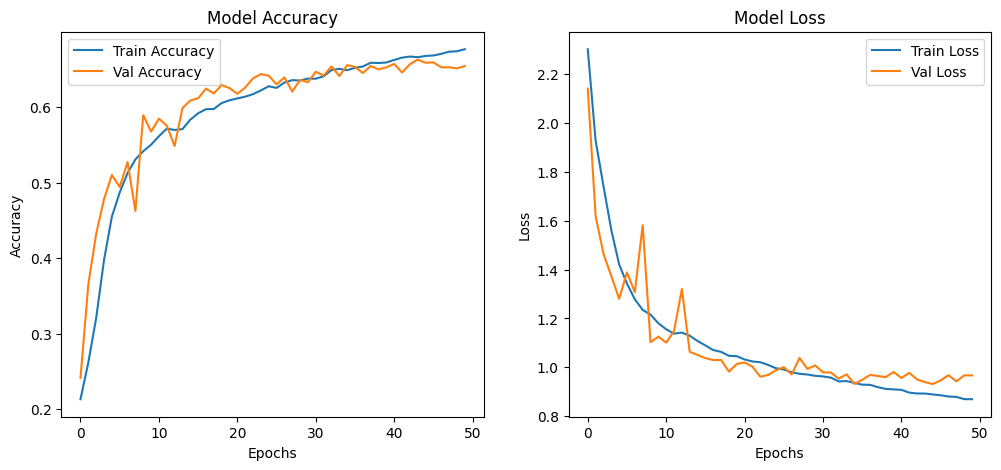

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ====== 1. PLOT TRAINING HISTORY ======
def plot_history(history):
    # Accuracy
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title("Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# Call after training
plot_history(history)


In [ ]:
model.save("fer_cnn_model.keras")

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step


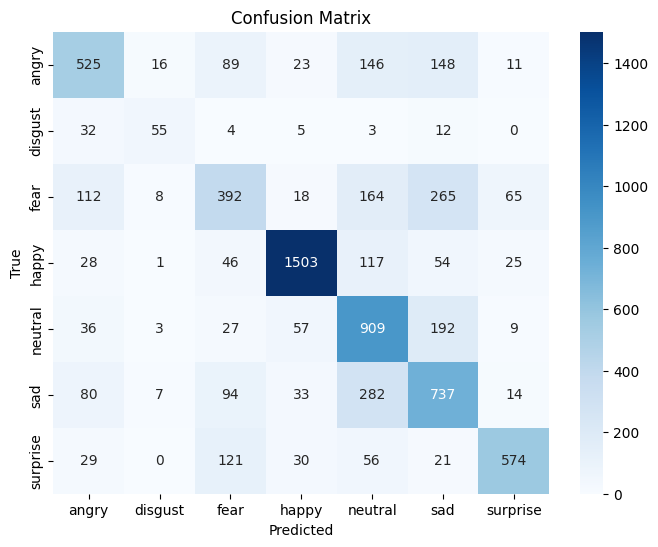

Classification Report:

              precision    recall  f1-score   support

       angry       0.62      0.55      0.58       958
     disgust       0.61      0.50      0.55       111
        fear       0.51      0.38      0.44      1024
       happy       0.90      0.85      0.87      1774
     neutral       0.54      0.74      0.62      1233
         sad       0.52      0.59      0.55      1247
    surprise       0.82      0.69      0.75       831

    accuracy                           0.65      7178
   macro avg       0.65      0.61      0.62      7178
weighted avg       0.67      0.65      0.65      7178



In [ ]:
# ====== 2. CONFUSION MATRIX ======

# Get test labels and predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ====== 3. CLASSIFICATION REPORT ======
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()

# Get filename
image_path = list(uploaded.keys())[0]
print("Uploaded:", image_path)


Saving Ursuela_Foto_Destacada_Actores_Garay.jpg to Ursuela_Foto_Destacada_Actores_Garay.jpg
Uploaded: Ursuela_Foto_Destacada_Actores_Garay.jpg


In [ ]:
# Load image
img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Resize to 48x48
resized = cv2.resize(gray, (48, 48))

# Normalize and reshape for model input
img_array = resized.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=-1)  # Add channel dimension
img_array = np.expand_dims(img_array, axis=0)   # Add batch dimension


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Emotion: happy


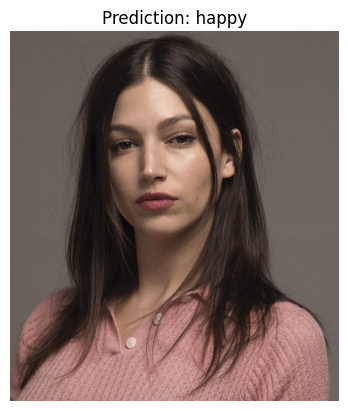

In [ ]:
# Predict
pred = model.predict(img_array)
emotion_class = np.argmax(pred)
emotion_label = list(train_generator.class_indices.keys())[emotion_class]

print("Predicted Emotion:", emotion_label)

# Show original image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {emotion_label}")
plt.axis("off")
plt.show()


In [ ]:
# Predict probabilities
pred = model.predict(img_array)[0]

# Map class indices to emotion labels
class_labels = list(train_generator.class_indices.keys())

# Get top prediction
emotion_class = np.argmax(pred)
emotion_label = class_labels[emotion_class]
confidence = pred[emotion_class] * 100

print("Prediction:", emotion_label)
print("Confidence: {:.2f}%".format(confidence))

# Show all class probabilities
for label, prob in zip(class_labels, pred):
    print(f"{label}: {prob*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediction: happy
Confidence: 38.69%
angry: 5.08%
disgust: 0.02%
fear: 24.06%
happy: 38.69%
neutral: 3.29%
sad: 21.88%
surprise: 6.97%


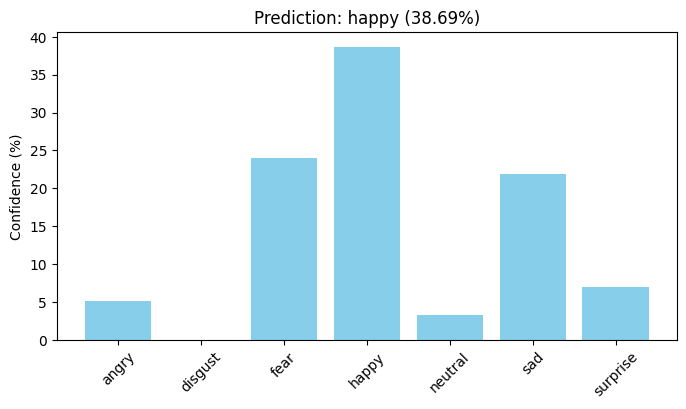

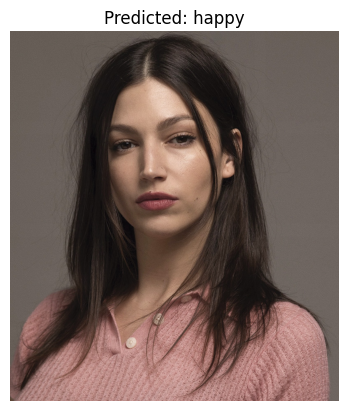

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(class_labels, pred*100, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Confidence (%)")
plt.title(f"Prediction: {emotion_label} ({confidence:.2f}%)")
plt.show()A

# Show original image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {emotion_label}")
plt.axis("off")
plt.show()


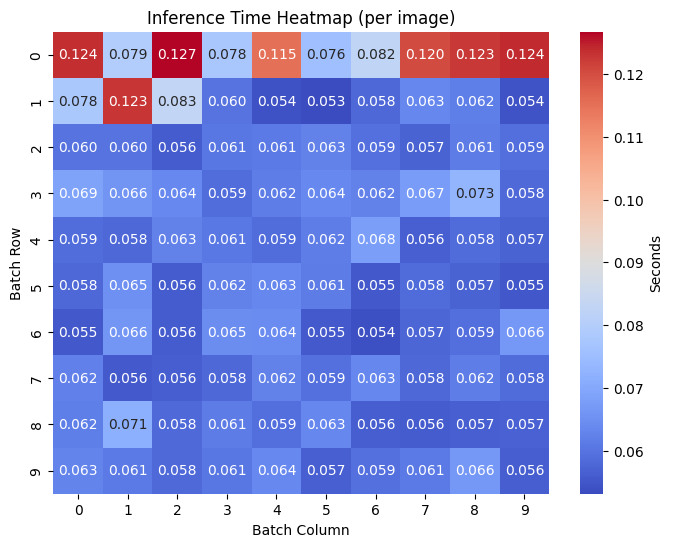

In [ ]:
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# Directory for test images
test_path = "/content/fer2013_1/test"

# Collect some images for inference timing
img_files = []
for root, dirs, files in os.walk(test_path):
    for file in files:
        if file.endswith(".jpg") or file.endswith(".png"):
            img_files.append(os.path.join(root, file))
# limit to first 100 samples for demo
img_files = img_files[:100]

inference_times = []

for img_path in img_files:
    # Load image
    img = image.load_img(img_path, target_size=(48,48), color_mode="grayscale")
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Time inference
    start = time.time()
    _ = model.predict(img_array, verbose=0)
    end = time.time()

    inference_times.append(end-start)

# Convert to numpy
inference_times = np.array(inference_times).reshape(10,10)  # reshape for heatmap (10x10)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(inference_times, annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label': 'Seconds'})
plt.title("Inference Time Heatmap (per image)")
plt.xlabel("Batch Column")
plt.ylabel("Batch Row")
plt.show()
